In [196]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [197]:
from config import path_to_repository_Zeyad 
from analysis import BallBearingData # class for extracting all data from application and reapplication for ADC, IMU, and Camera Triggers
from analysis import DLC3DBendAngles # class for taking DLC 3d point data and converting to angles 
from analysis import bender_class # class for normalizing adc data, analyzing autobender tests
from analysis_adc_cam import ADC_CAM
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 11_2_25 Data

In [198]:
# Upload Trials from particpant
# Upload only the parent *date* folder (e.g., "9_19_25").
# If something fails, verify your folder structure matches the "9_19_25" example.

root_dir="CSV Data/11_2_25"
folder_suffix_first  = "B1_adab"       # e.g.  9_19_25_B1_slow
folder_suffix_second = "B2_adab"       # e.g.  9_19_25_B2_slow

#10_28_25 (Tom)
#10_29_25 (bending data might be okay...check...resistance changing)
#11_2_25 (good)
#11_4_25 (good)
#11_7_25 (missing 90 degree cam calibration)

##################### raw adc or imu data for any test ###############################



cam = ADC_CAM(
    root_dir=root_dir,
    path_to_repo=path_to_repository_Zeyad,
    folder_suffix_first=folder_suffix_first,
    folder_suffix_second=folder_suffix_second,
)

first_trials  = cam.load_first()
second_trials = cam.load_second()

n_first  = len(first_trials)
n_second = len(second_trials)

print("Number of first trials:", n_first)
print("Number of second trials:", n_second)


Number of first trials: 3
Number of second trials: 3


## Obtain Raw ADC Traces For Tasks 

In [199]:
adc_trials_first  = cam.extract_adc_dfs_by_trial(first_trials)
adc_trials_second = cam.extract_adc_dfs_by_trial(second_trials)

print("Number of first ADC trials:", len(adc_trials_first))
print("Number of second ADC trials:", len(adc_trials_second))


Number of first ADC trials: 3
Number of second ADC trials: 3


Motion/Rest filtering functions + intervals

## Obtain Camera/Protracto Calibration Data and Plot 

,set,folder_name,angle_raw_deg,angle_snap_deg,adc_column,adc_mean,source_path
0,1,2025_11_02_14_18_17_B_calib86,86.0,NaN,adc_ch3,8.817015e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
1,2,2025_11_02_15_33_15_B_calib86,86.0,NaN,adc_ch3,8.867314e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
2,1,2025_11_02_14_13_33_B_calib22,22.0,22.0,adc_ch3,9.063745e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
3,2,2025_11_02_15_30_35_B_calib22,22.0,22.0,adc_ch3,9.095699e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
4,1,2025_11_02_14_14_38_B_calib45,45.0,45.0,adc_ch3,8.999078e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
5,2,2025_11_02_15_31_30_B_calib45,45.0,45.0,adc_ch3,9.014002e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
6,1,2025_11_02_14_16_46_B_calib67,67.0,67.0,adc_ch3,8.838729e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
7,2,2025_11_02_15_32_19_B_calib67,67.0,67.0,adc_ch3,8.934240e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
8,1,2025_11_02_14_12_34_B_calib0,0.0,0.0,adc_ch3,9.110725e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
9,2,2025_11_02_15_29_45_B_calib0,0.0,0.0,adc_ch3,9.147190e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...


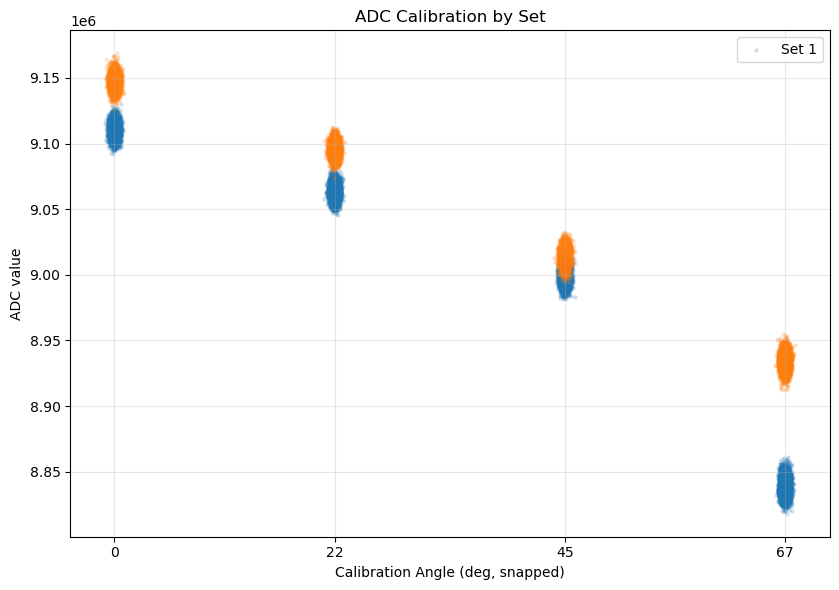

In [200]:
adc_cal_df = cam.extract_calib_means_by_set(
    adc_column="adc_ch3",             # or None to auto-pick
    exclude_name_contains=("C_Block",),
    exclude_sets=(3, 4),
    make_plot=True,
    overlay_mean=False,
    point_alpha=0.15,                 # maybe lower alpha for all points
    point_size=5,                     # smaller points for dense clouds
    jitter=0.25,
    snap_tol_deg=4.0,
    plot_all_data=True,               # <-- THIS plots all ADC samples
    canonical_angles=(0, 22, 45, 67), #  no 90
)

adc_cal_df

## Convert ADC Values to Angles Using Camera / Protractor Calibration 

In [201]:
out_cam_11_2 = cam.calibrate_trials_with_camera(
    adc_trials_first=adc_trials_first,
    adc_trials_second=adc_trials_second,
    adc_column="adc_ch3",
    poly_order=2,
    calib_kwargs=dict(
        adc_column="adc_ch3",
        exclude_name_contains=("C_Block",),
        exclude_sets=(3, 4),
        make_plot=False,
        overlay_mean=False,
        point_alpha=0.25,
        point_size=10,
        jitter=0.25,
        snap_tol_deg=4.0,
    ),
    clamp_theta=True,
    deg_min=0.0,
    deg_max=90.0,
)

adc_first_theta_11_2  = out_cam_11_2["adc_trials_first_theta"]
adc_second_theta_11_2 = out_cam_11_2["adc_trials_second_theta"]

In [202]:
ts = (
    adc_first_theta_11_2[0]["timestamp"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(12)
)

ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")

adc_first_theta_11_2[0]["time_sec"] = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()

adc_first_theta_11_2[0]

,timestamp,adc_ch0,adc_ch1,adc_ch2,adc_ch3,trial_index,source_path,theta_cam_cal,time_sec
0,151211498972,0,0,0,9148233,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,0.000000
1,151211498972,0,0,0,9142772,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,0.000000
2,151211498972,0,0,0,9143113,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,0.000000
3,151211498972,0,0,0,9147038,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,0.000000
4,151211498972,0,0,0,9132703,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,0.000000
...,...,...,...,...,...,...,...,...,...
6955,151221494917,0,0,0,9154377,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,9.995945
6956,151221494917,0,0,0,9150964,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,9.995945
6957,151221494917,0,0,0,9150964,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,9.995945
6958,151221494917,0,0,0,9151988,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.0,9.995945


## Calibration Curves

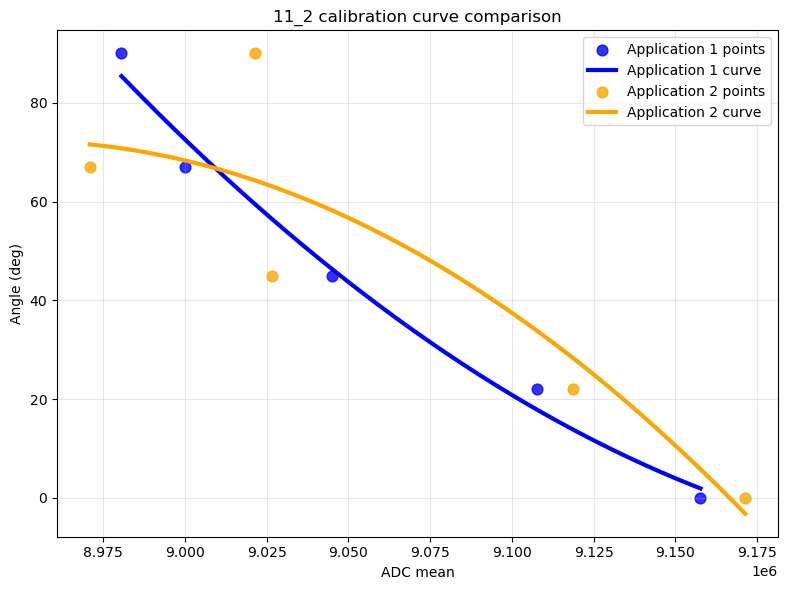

In [203]:
# ==========================================================
# Calibration curve comparison – Participant 11_2
# ==========================================================


calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

keep_angles = [0, 22, 45, 67, 90]

calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

# use adc_mean, not adc_ch3
calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df["angle_snap_deg"] = pd.to_numeric(calib_df["angle_snap_deg"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean", "angle_snap_deg"])

plt.figure(figsize=(8, 6))

colors = {1: "blue", 2: "orange"}

for set_id in [1, 2]:
    sub = calib_df[calib_df["set"] == set_id].copy()

    if sub.empty:
        continue

    plt.scatter(
        sub["adc_mean"],
        sub["angle_snap_deg"],
        s=60,
        alpha=0.8,
        color=colors[set_id],
        label=f"Application {set_id} points"
    )

    if set_id in coeffs:
        poly = np.poly1d(coeffs[set_id])

        x_line = np.linspace(sub["adc_mean"].min(), sub["adc_mean"].max(), 400)
        y_line = poly(x_line)

        plt.plot(
            x_line,
            y_line,
            color=colors[set_id],
            linewidth=3,
            label=f"Application {set_id} curve"
        )

plt.xlabel("ADC mean")
plt.ylabel("Angle (deg)")
plt.title("11_2 calibration curve comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

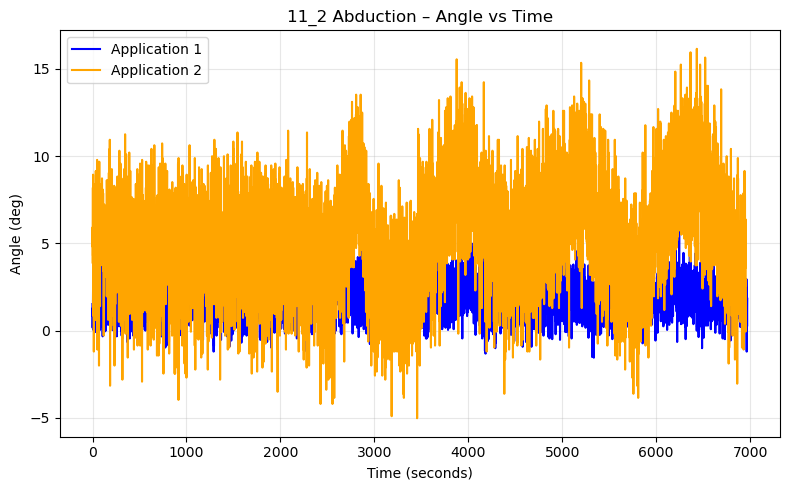

In [204]:
# ==========================================================
# 11_7 - Convert ADC to angle and plot vs time
# with robust time-axis handling
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

coeffs = out_cam["coeffs"]

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

trial_index = 0

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

# convert ADC to angle
df1["theta_from_adc"] = poly_app1(df1["adc_ch3"])
df2["theta_from_adc"] = poly_app2(df2["adc_ch3"])

# helper to choose or create time column
def get_time_series(df):
    possible_time_cols = ["relative_seconds", "time", "seconds", "t", "time_s"]
    
    for col in possible_time_cols:
        if col in df.columns:
            return df[col]

    # if no time column exists, use the index
    return df.index.to_series().reset_index(drop=True)

t1 = get_time_series(df1)
t2 = get_time_series(df2)

plt.figure(figsize=(8, 5))

plt.plot(
    t1,
    df1["theta_from_adc"].reset_index(drop=True),
    color="blue",
    label="Application 1"
)

plt.plot(
    t2,
    df2["theta_from_adc"].reset_index(drop=True),
    color="orange",
    label="Application 2"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Angle (deg)")
plt.title("11_2 Abduction – Angle vs Time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Calibration Curve Normalization Comparison

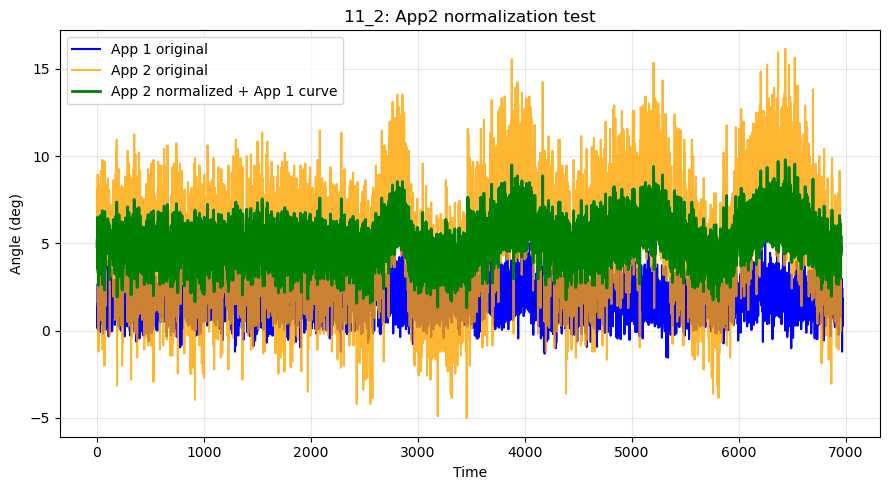

11_2 summary:
App 1 calibration ADC range: 8980625.72 to 9157667.41
App 2 calibration ADC range: 8970938.32 to 9171346.07
Mean App1 angle: 1.93
Mean App2 original angle: 5.32
Mean App2 normalized angle: 5.06


In [205]:
# ==========================================================
# 11_2: Test App2 min/max normalization + App1 calibration
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

trial_index = 0

calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

# keep only relevant angles for 11_2
keep_angles = [0, 22, 45, 67, 90]
calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean"])

# calibration ADC ranges
adc1 = calib_df[calib_df["set"] == 1]["adc_mean"]
adc2 = calib_df[calib_df["set"] == 2]["adc_mean"]

adc1_min, adc1_max = adc1.min(), adc1.max()
adc2_min, adc2_max = adc2.min(), adc2.max()

def normalize_app2_to_app1(adc):
    return (adc - adc2_min) / (adc2_max - adc2_min) * (adc1_max - adc1_min) + adc1_min

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

df1["theta_app1"] = poly_app1(df1["adc_ch3"])
df2["theta_app2"] = poly_app2(df2["adc_ch3"])

df2["adc_norm_to_app1"] = normalize_app2_to_app1(df2["adc_ch3"])
df2["theta_app2_norm_using_app1"] = poly_app1(df2["adc_norm_to_app1"])

# time axis
df1["time"] = np.arange(len(df1))
df2["time"] = np.arange(len(df2))

plt.figure(figsize=(9, 5))

plt.plot(df1["time"], df1["theta_app1"], color="blue", label="App 1 original")
plt.plot(df2["time"], df2["theta_app2"], color="orange", alpha=0.8, label="App 2 original")
plt.plot(df2["time"], df2["theta_app2_norm_using_app1"], color="green", linewidth=2, label="App 2 normalized + App 1 curve")

plt.xlabel("Time")
plt.ylabel("Angle (deg)")
plt.title("11_2: App2 normalization test")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("11_2 summary:")
print(f"App 1 calibration ADC range: {adc1_min:.2f} to {adc1_max:.2f}")
print(f"App 2 calibration ADC range: {adc2_min:.2f} to {adc2_max:.2f}")
print(f"Mean App1 angle: {df1['theta_app1'].mean():.2f}")
print(f"Mean App2 original angle: {df2['theta_app2'].mean():.2f}")
print(f"Mean App2 normalized angle: {df2['theta_app2_norm_using_app1'].mean():.2f}")

## Plotting The Abduction Data. Note that no camera data is present for these tests 

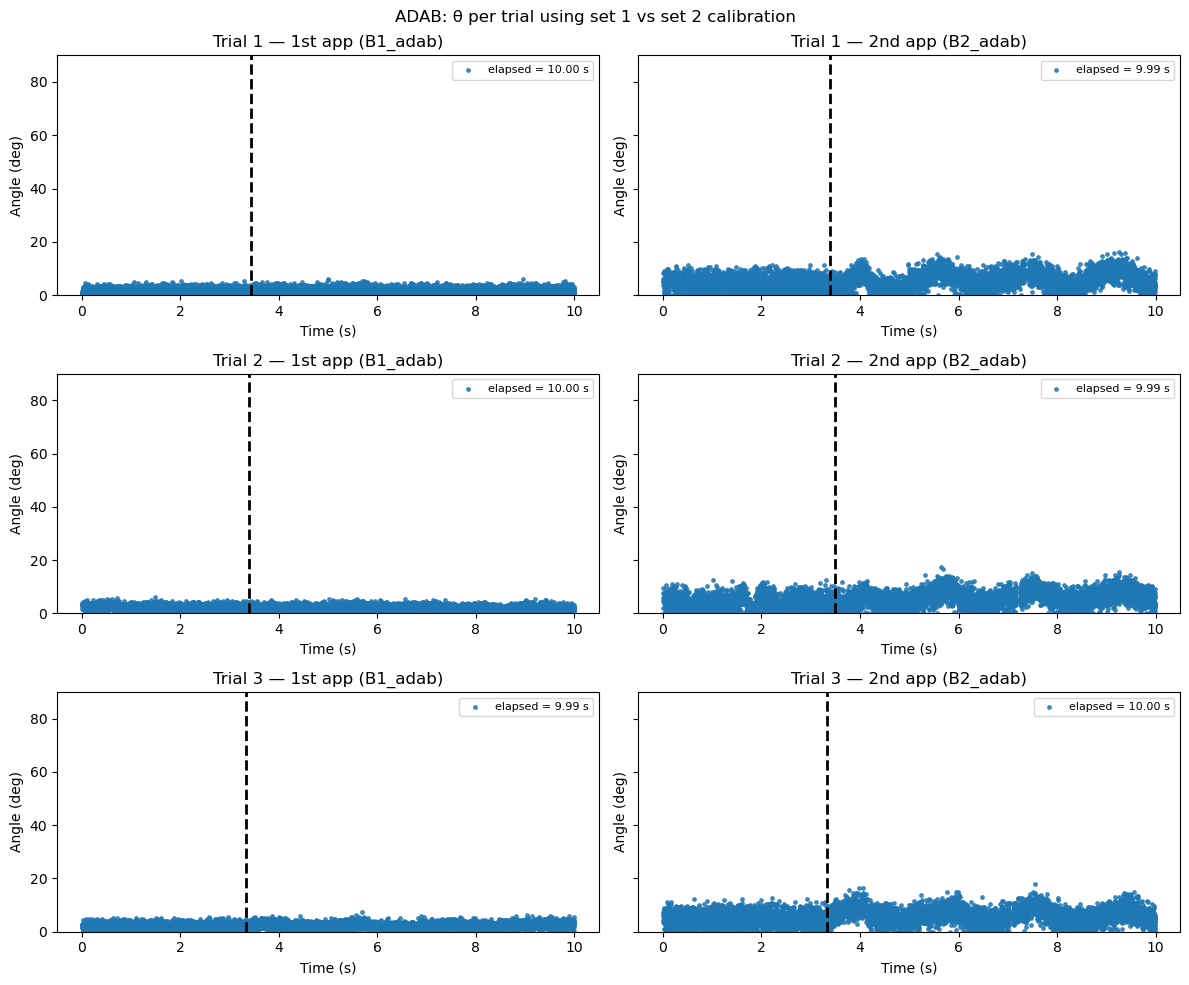

In [206]:
calib_df = out_cam.get("calib_df", None)
coeffs   = out_cam.get("coeffs", None)

# ---- 1) Skip unless ADAB pairing ----
allowed = {"B1_adab", "B2_adab"}
if {folder_suffix_first, folder_suffix_second} != allowed:
    print("SKIP: suffixes are not exactly {'B1_adab','B2_adab'}")
else:

    # ---- 2) Ensure we have coeffs for set 1 and set 2 ----
    if not isinstance(coeffs, dict):
        coeffs = {}

    if (1 not in coeffs or 2 not in coeffs):
        if calib_df is None or getattr(calib_df, "empty", True):
            print("WARNING: calib_df is empty/None and coeffs missing for set 1/2 -> cannot compute angles.")
        else:
            poly_order = 2
            for s in (1, 2):
                sub = calib_df[(calib_df["set"] == s) & calib_df["angle_snap_deg"].notna()]
                if len(sub) >= (poly_order + 1):
                    x_fit = sub["adc_mean"].to_numpy(dtype=float)
                    y_fit = sub["angle_snap_deg"].to_numpy(dtype=float)
                    coeffs[s] = np.polyfit(x_fit, y_fit, poly_order)

    # ---- 3) Convert timestamp strings HHMMSSffffff to elapsed seconds ----
    def make_elapsed_time(df, timestamp_col="timestamp"):
        """
        Convert HHMMSSffffff timestamp strings to elapsed seconds.
        Keeps ALL rows; does not collapse repeated timestamps.
        """
        ts = (
            df[timestamp_col]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.strip()
            .str.zfill(12)
        )

        ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")
        elapsed = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()
        return elapsed.to_numpy(dtype=float)

    # ---- 4) Helper: get theta series for ALL rows ----
    def get_theta_series(
        trial_df,
        set_id,
        adc_column="adc_ch3",
        clamp=True,
        deg_min=0.0,
        deg_max=90.0,
    ):
        if trial_df is None or not hasattr(trial_df, "columns"):
            return None

        df = trial_df.copy()

        # ---- y values ----
        if "theta_cam_cal" in df.columns:
            y = pd.to_numeric(df["theta_cam_cal"], errors="coerce").to_numpy(dtype=float)
        else:
            if set_id not in coeffs:
                return None
            if adc_column not in df.columns:
                return None

            adc_vals = pd.to_numeric(df[adc_column], errors="coerce").to_numpy(dtype=float)
            p = np.poly1d(coeffs[set_id])
            y = p(adc_vals)

            if clamp:
                y = np.clip(y, deg_min, deg_max)

        # ---- x values (elapsed time) ----
        if "timestamp" in df.columns:
            x = make_elapsed_time(df)
        else:
            x = np.arange(len(y), dtype=float)

        # ---- keep only finite pairs for plotting ----
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        elapsed_sec = float(x[-1] - x[0]) if len(x) > 1 else np.nan
        return x, y, elapsed_sec

    # NEW: movement start times for FIRST application
    movement_start_times_app1 = {
        0: 3.44,   # Trial 1 — replace with your exact timestamp
        1: 3.39,   # Trial 2 — replace with your exact timestamp
        2: 3.34,   # Trial 3 — replace with your exact timestamp
    }

    # NEW: movement start times for SECOND application
    movement_start_times_app2 = {
        0: 3.39,   # Trial 1
        1: 3.49,   # Trial 2
        2: 3.34,   # Trial 3
    }

    # ---- 5) Decide how many rows to plot ----
    n = min(3, len(adc_first_theta), len(adc_second_theta))
    if n == 0:
        print("Nothing to plot: n=0 (your trial lists are empty).")
    else:
        fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

        for r in range(3):
            for c in range(2):
                if r >= n:
                    axes[r, c].axis("off")

        missing = 0

        for i in range(n):
            # ---- LEFT COLUMN (set 1) ----
            ax = axes[i, 0]

            xy = get_theta_series(
                adc_first_theta[i],
                set_id=1,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 1)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for FIRST application
                if i in movement_start_times_app1:
                    ax.axvline(
                        x=movement_start_times_app1[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 1st app ({folder_suffix_first})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

            # ---- RIGHT COLUMN (set 2) ----
            ax = axes[i, 1]

            xy = get_theta_series(
                adc_second_theta[i],
                set_id=2,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 2)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for SECOND application
                if i in movement_start_times_app2:
                    ax.axvline(
                        x=movement_start_times_app2[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 2nd app ({folder_suffix_second})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

        if missing > 0:
            print(f"NOTE: {missing} subplot(s) missing theta.")

        fig.suptitle("ADAB: θ per trial using set 1 vs set 2 calibration", y=0.98)
        plt.tight_layout()
        plt.show()

## Standard Deviation Calculations 1st Application 11-2 (rest / moving)

In [207]:
# use participant-specific calibrated output
adc_first_theta_11_2 = out_cam_11_2["adc_trials_first_theta"]

# onset times (s) for first application trials 1–3
onsets = [3.44, 3.39, 3.34]

trial_names = [
    "11_2_app1_trial_1",
    "11_2_app1_trial_2",
    "11_2_app1_trial_3"
]

results_11_2_app1 = []

for i, onset in enumerate(onsets):
    df = adc_first_theta_11_2[i].copy()

    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results_11_2_app1.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

df_11_2_app1 = pd.DataFrame(results_11_2_app1).set_index("trial")

print(df_11_2_app1)
print("\nMean rest std:", df_11_2_app1["rest_std_deg"].mean())
print("Mean motion std:", df_11_2_app1["motion_std_deg"].mean())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_2_app1_trial_1     3.44    2395      4495           0.0             0.0
11_2_app1_trial_2     3.39    2360      4540           0.0             0.0
11_2_app1_trial_3     3.34    2320      4570           0.0             0.0

Mean rest std: 0.0
Mean motion std: 0.0


## Standard Deviation Calculations 2nd Application 11-2 (rest / moving)

In [208]:
adc_second_theta = out_cam_11_2["adc_trials_second_theta"]

# onset times (seconds) for second application trials
onsets = [3.39, 3.49, 3.34]

trial_names = [
    "11_2_app2_trial_1",
    "11_2_app2_trial_2",
    "11_2_app2_trial_3"
]

results = []

for i, onset in enumerate(onsets):

    df = adc_second_theta[i].copy()

    # convert timestamp to elapsed seconds
    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    # REST segment
    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    # MOTION segment
    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

df_11_2_app2 = pd.DataFrame(results).set_index("trial")

print(df_11_2_app2)

print("\nMean rest std:", df_11_2_app2["rest_std_deg"].mean())
print("Mean motion std:", df_11_2_app2["motion_std_deg"].mean())
print("Std of rest stds:", df_11_2_app2["rest_std_deg"].std())
print("Std of motion stds:", df_11_2_app2["motion_std_deg"].std())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_2_app2_trial_1     3.39    2365      4530      0.230677        0.467223
11_2_app2_trial_2     3.49    2430      4445      0.294593        0.289201
11_2_app2_trial_3     3.34    2325      4565      0.710665        1.123329

Mean rest std: 0.4119781522623227
Mean motion std: 0.6265842437058445
Std of rest stds: 0.26063699096342396
Std of motion stds: 0.4393056118191787


## 11_4_25 Data

In [209]:
# Upload Trials from particpant
# Upload only the parent *date* folder (e.g., "9_19_25").
# If something fails, verify your folder structure matches the "9_19_25" example.

root_dir="CSV Data/11_4_25"
folder_suffix_first_  = "B1_adab"       # e.g.  9_19_25_B1_slow
folder_suffix_second = "B2_adab"       # e.g.  9_19_25_B2_slow

#10_28_25 (Tom)
#10_29_25 (bending data might be okay...check...resistance changing)
#11_2_25 (good)
#11_4_25 (good)
#11_7_25 (missing 90 degree cam calibration)

##################### raw adc or imu data for any test ###############################



cam = ADC_CAM(
    root_dir=root_dir,
    path_to_repo=path_to_repository_Zeyad,
    folder_suffix_first=folder_suffix_first,
    folder_suffix_second=folder_suffix_second,
)

first_trials  = cam.load_first()
second_trials = cam.load_second()

n_first  = len(first_trials)
n_second = len(second_trials)

print("Number of first trials:", n_first)
print("Number of second trials:", n_second)


Number of first trials: 3
Number of second trials: 3


## Obtain Raw ADC Traces For Tasks 

In [210]:
adc_trials_first  = cam.extract_adc_dfs_by_trial(first_trials)
adc_trials_second = cam.extract_adc_dfs_by_trial(second_trials)

print("Number of first ADC trials:", len(adc_trials_first))
print("Number of second ADC trials:", len(adc_trials_second))


Number of first ADC trials: 3
Number of second ADC trials: 3


## Obtain Camera/Protracto Calibration Data and Plot 

,set,folder_name,angle_raw_deg,angle_snap_deg,adc_column,adc_mean,source_path
0,1,2025_11_04_14_55_55_B_calib45,45.0,45.0,adc_ch3,9.045078e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
1,2,2025_11_04_15_50_06_B_calib45,45.0,45.0,adc_ch3,9.026803e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
2,1,2025_11_04_14_58_59_B_calib87,87.0,NaN,adc_ch3,8.980626e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
3,2,2025_11_04_15_52_18_B_calib87,87.0,NaN,adc_ch3,9.021524e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
4,1,2025_11_04_14_57_14_B_calib67,67.0,67.0,adc_ch3,9.000017e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
5,2,2025_11_04_15_51_13_B_calib67,67.0,67.0,adc_ch3,8.970938e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
6,1,2025_11_04_14_54_55_B_calib22,22.0,22.0,adc_ch3,9.107699e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
7,2,2025_11_04_15_49_22_B_calib22,22.0,22.0,adc_ch3,9.118603e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
8,1,2025_11_04_14_53_42_B_calib0,0.0,0.0,adc_ch3,9.157667e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
9,2,2025_11_04_15_48_21_B_calib0,0.0,0.0,adc_ch3,9.171346e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...


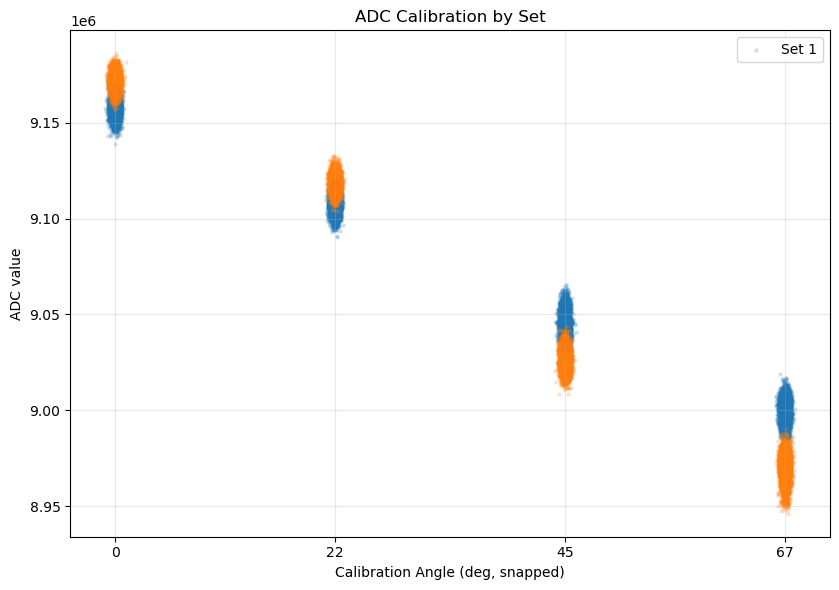

In [211]:
adc_cal_df = cam.extract_calib_means_by_set(
    adc_column="adc_ch3",             # or None to auto-pick
    exclude_name_contains=("C_Block",),
    exclude_sets=(3, 4),
    make_plot=True,
    overlay_mean=False,
    point_alpha=0.15,                 # maybe lower alpha for all points
    point_size=5,                     # smaller points for dense clouds
    jitter=0.25,
    snap_tol_deg=4.0,
    plot_all_data=True,               # <-- THIS plots all ADC samples
    canonical_angles=(0, 22, 45, 67), #  no 90
)

adc_cal_df


## Convert ADC Values to Angles Using Camera / Protractor Calibration 

In [212]:
out_cam = cam.calibrate_trials_with_camera(
    adc_trials_first=adc_trials_first,
    adc_trials_second=adc_trials_second,
    adc_column="adc_ch3",
    poly_order=2,
    calib_kwargs=dict(
        adc_column="adc_ch3",
        exclude_name_contains=("C_Block",),
        exclude_sets=(3, 4),
        make_plot=False,
        overlay_mean=False,
        point_alpha=0.25,
        point_size=10,
        jitter=0.25,
        snap_tol_deg=4.0,
    ),
    clamp_theta=True,   # <--- enable clamping
    deg_min=0.0,
    deg_max=90.0,
)

adc_first_theta  = out_cam["adc_trials_first_theta"]
adc_second_theta = out_cam["adc_trials_second_theta"]

In [213]:
ts = (
    adc_first_theta[0]["timestamp"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(12)
)

ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")

adc_first_theta[0]["time_sec"] = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()

adc_first_theta[0]

,timestamp,adc_ch0,adc_ch1,adc_ch2,adc_ch3,trial_index,source_path,theta_cam_cal,time_sec
0,153720555938,0,0,0,9159155,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.520357,0.000000
1,153720555938,0,0,0,9164617,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.160627,0.000000
2,153720555938,0,0,0,9162910,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.577881,0.000000
3,153720555938,0,0,0,9160009,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.303036,0.000000
4,153720555938,0,0,0,9162057,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.789006,0.000000
...,...,...,...,...,...,...,...,...,...
6965,153730555846,0,0,0,9158985,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.563827,9.999908
6966,153730555846,0,0,0,9163251,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.493969,9.999908
6967,153730555846,0,0,0,9164275,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.243664,9.999908
6968,153730555846,0,0,0,9162227,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.746790,9.999908


## Calibration Curve

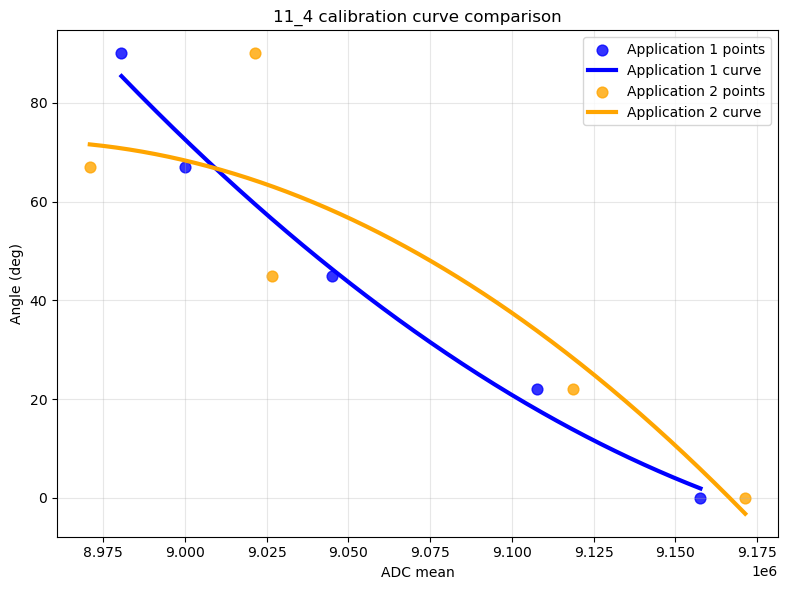

In [214]:
# ==========================================================
# Calibration curve comparison – Participant 11_4
# ==========================================================

calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

keep_angles = [0, 22, 45, 67, 90]

calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df["angle_snap_deg"] = pd.to_numeric(calib_df["angle_snap_deg"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean", "angle_snap_deg"])

plt.figure(figsize=(8, 6))

colors = {1: "blue", 2: "orange"}

for set_id in [1, 2]:
    sub = calib_df[calib_df["set"] == set_id].copy()

    if sub.empty:
        continue

    plt.scatter(
        sub["adc_mean"],
        sub["angle_snap_deg"],
        s=60,
        alpha=0.8,
        color=colors[set_id],
        label=f"Application {set_id} points"
    )

    if set_id in coeffs:
        poly = np.poly1d(coeffs[set_id])

        x_line = np.linspace(sub["adc_mean"].min(), sub["adc_mean"].max(), 400)
        y_line = poly(x_line)

        plt.plot(
            x_line,
            y_line,
            color=colors[set_id],
            linewidth=3,
            label=f"Application {set_id} curve"
        )

plt.xlabel("ADC mean")
plt.ylabel("Angle (deg)")
plt.title("11_4 calibration curve comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

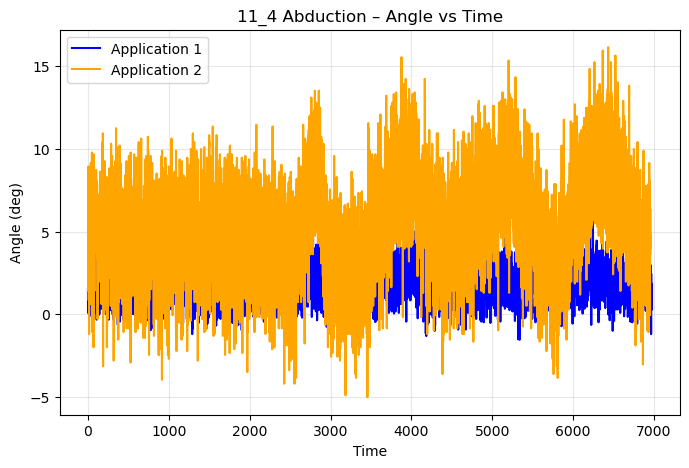

In [215]:
# ==========================================================
# 11_4 Abduction – ADC converted to angle vs time
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

coeffs = out_cam["coeffs"]

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

trial_index = 0

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

# convert ADC to angle
df1["theta_from_adc"] = poly_app1(df1["adc_ch3"])
df2["theta_from_adc"] = poly_app2(df2["adc_ch3"])

# create time axis if needed
df1["time"] = np.arange(len(df1))
df2["time"] = np.arange(len(df2))

plt.figure(figsize=(8,5))

plt.plot(
    df1["time"],
    df1["theta_from_adc"],
    color="blue",
    label="Application 1"
)

plt.plot(
    df2["time"],
    df2["theta_from_adc"],
    color="orange",
    label="Application 2"
)

plt.xlabel("Time")
plt.ylabel("Angle (deg)")
plt.title("11_4 Abduction – Angle vs Time")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

## Normalized Calibration Curve Comparison

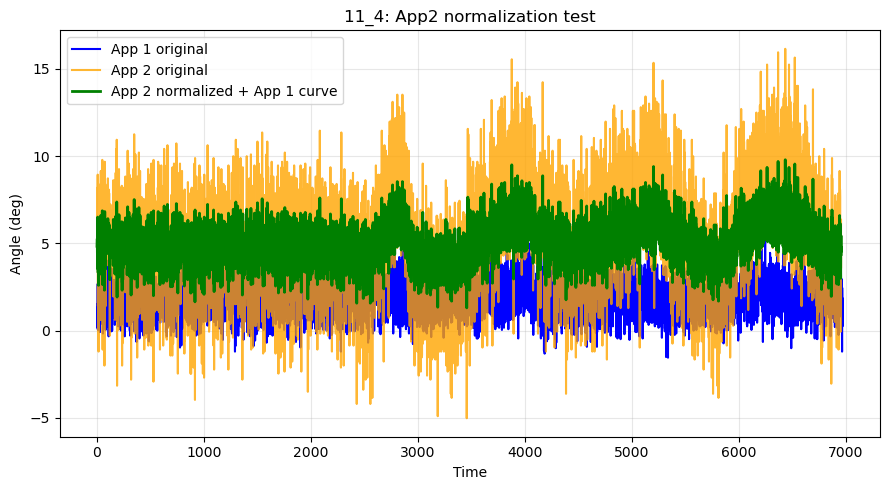

11_4 summary:
App 1 calibration ADC range: 8980625.72 to 9157667.41
App 2 calibration ADC range: 8970938.32 to 9171346.07
Mean App1 angle: 1.93
Mean App2 original angle: 5.32
Mean App2 normalized angle: 5.06


In [216]:
# ==========================================================
# 11_4: Test App2 min/max normalization + App1 calibration
# ==========================================================

trial_index = 0

calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

# keep only relevant angles for 11_4
keep_angles = [0, 22, 45, 67, 90]
calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean"])

# calibration ADC ranges
adc1 = calib_df[calib_df["set"] == 1]["adc_mean"]
adc2 = calib_df[calib_df["set"] == 2]["adc_mean"]

adc1_min, adc1_max = adc1.min(), adc1.max()
adc2_min, adc2_max = adc2.min(), adc2.max()

def normalize_app2_to_app1(adc):
    return (adc - adc2_min) / (adc2_max - adc2_min) * (adc1_max - adc1_min) + adc1_min

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

df1["theta_app1"] = poly_app1(df1["adc_ch3"])
df2["theta_app2"] = poly_app2(df2["adc_ch3"])

df2["adc_norm_to_app1"] = normalize_app2_to_app1(df2["adc_ch3"])
df2["theta_app2_norm_using_app1"] = poly_app1(df2["adc_norm_to_app1"])

# time axis
df1["time"] = np.arange(len(df1))
df2["time"] = np.arange(len(df2))

plt.figure(figsize=(9, 5))

plt.plot(df1["time"], df1["theta_app1"], color="blue", label="App 1 original")
plt.plot(df2["time"], df2["theta_app2"], color="orange", alpha=0.8, label="App 2 original")
plt.plot(df2["time"], df2["theta_app2_norm_using_app1"], color="green", linewidth=2, label="App 2 normalized + App 1 curve")

plt.xlabel("Time")
plt.ylabel("Angle (deg)")
plt.title("11_4: App2 normalization test")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("11_4 summary:")
print(f"App 1 calibration ADC range: {adc1_min:.2f} to {adc1_max:.2f}")
print(f"App 2 calibration ADC range: {adc2_min:.2f} to {adc2_max:.2f}")
print(f"Mean App1 angle: {df1['theta_app1'].mean():.2f}")
print(f"Mean App2 original angle: {df2['theta_app2'].mean():.2f}")
print(f"Mean App2 normalized angle: {df2['theta_app2_norm_using_app1'].mean():.2f}")

## Plotting The Abduction Data. Note that no camera data is present for these tests 

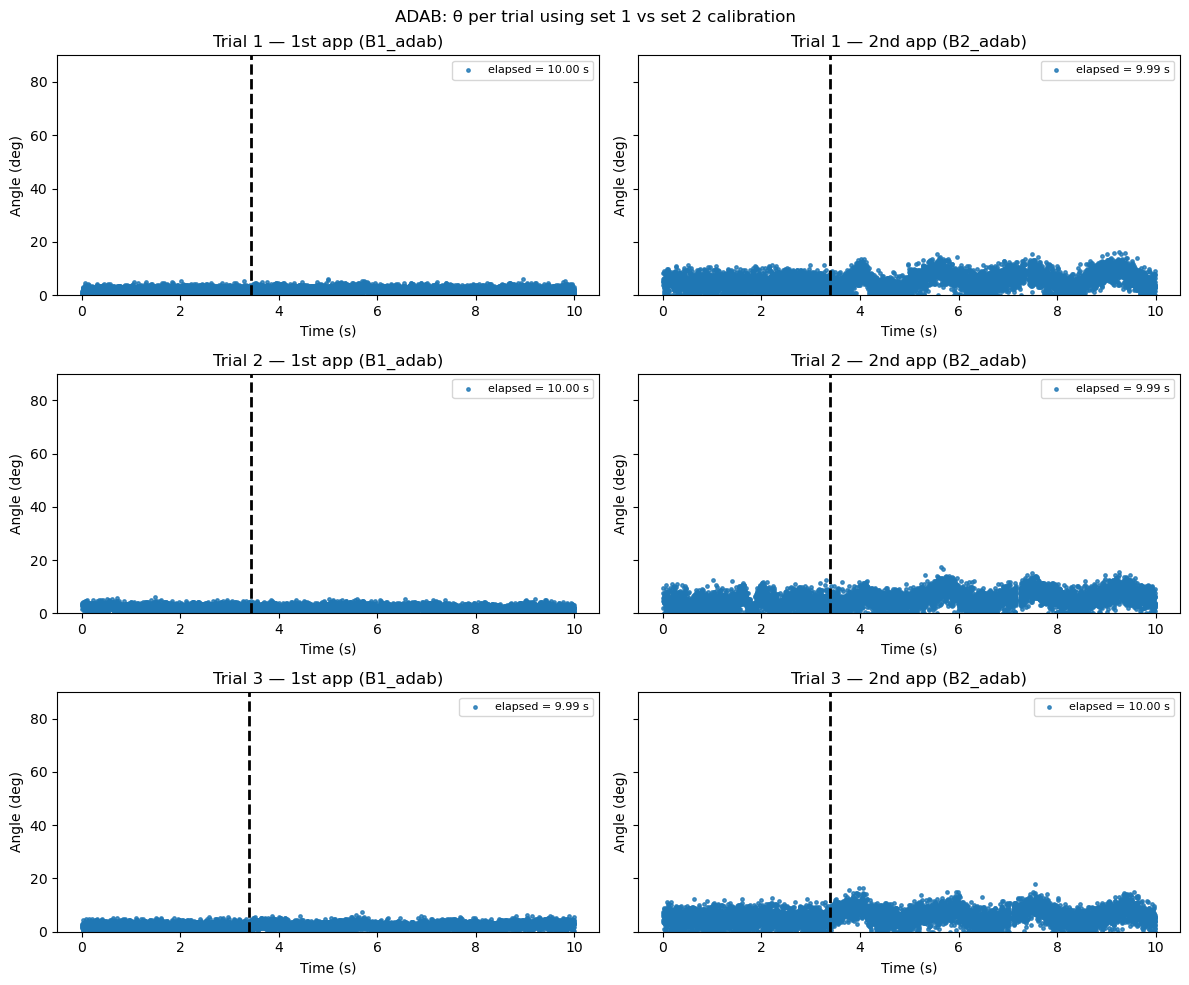

In [217]:
calib_df = out_cam.get("calib_df", None)
coeffs   = out_cam.get("coeffs", None)

# ---- 1) Skip unless ADAB pairing ----
allowed = {"B1_adab", "B2_adab"}
if {folder_suffix_first, folder_suffix_second} != allowed:
    print("SKIP: suffixes are not exactly {'B1_adab','B2_adab'}")
else:

    # ---- 2) Ensure we have coeffs for set 1 and set 2 ----
    if not isinstance(coeffs, dict):
        coeffs = {}

    if (1 not in coeffs or 2 not in coeffs):
        if calib_df is None or getattr(calib_df, "empty", True):
            print("WARNING: calib_df is empty/None and coeffs missing for set 1/2 -> cannot compute angles.")
        else:
            poly_order = 2
            for s in (1, 2):
                sub = calib_df[(calib_df["set"] == s) & calib_df["angle_snap_deg"].notna()]
                if len(sub) >= (poly_order + 1):
                    x_fit = sub["adc_mean"].to_numpy(dtype=float)
                    y_fit = sub["angle_snap_deg"].to_numpy(dtype=float)
                    coeffs[s] = np.polyfit(x_fit, y_fit, poly_order)

    # ---- 3) Convert timestamp strings HHMMSSffffff to elapsed seconds ----
    def make_elapsed_time(df, timestamp_col="timestamp"):
        """
        Convert HHMMSSffffff timestamp strings to elapsed seconds.
        Keeps ALL rows; does not collapse repeated timestamps.
        """
        ts = (
            df[timestamp_col]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.strip()
            .str.zfill(12)
        )

        ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")
        elapsed = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()
        return elapsed.to_numpy(dtype=float)

    # ---- 4) Helper: get theta series for ALL rows ----
    def get_theta_series(
        trial_df,
        set_id,
        adc_column="adc_ch3",
        clamp=True,
        deg_min=0.0,
        deg_max=90.0,
    ):
        if trial_df is None or not hasattr(trial_df, "columns"):
            return None

        df = trial_df.copy()

        # ---- y values ----
        if "theta_cam_cal" in df.columns:
            y = pd.to_numeric(df["theta_cam_cal"], errors="coerce").to_numpy(dtype=float)
        else:
            if set_id not in coeffs:
                return None
            if adc_column not in df.columns:
                return None

            adc_vals = pd.to_numeric(df[adc_column], errors="coerce").to_numpy(dtype=float)
            p = np.poly1d(coeffs[set_id])
            y = p(adc_vals)

            if clamp:
                y = np.clip(y, deg_min, deg_max)

        # ---- x values (elapsed time) ----
        if "timestamp" in df.columns:
            x = make_elapsed_time(df)
        else:
            x = np.arange(len(y), dtype=float)

        # ---- keep only finite pairs for plotting ----
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        elapsed_sec = float(x[-1] - x[0]) if len(x) > 1 else np.nan
        return x, y, elapsed_sec

    # NEW: movement start times for FIRST application
    movement_start_times_app1 = {
        0: 3.44,   # Trial 1 — replace with your exact timestamp
        1:  3.44,   # Trial 2 — replace with your exact timestamp
        2: 3.39,   # Trial 3 — replace with your exact timestamp
    }

    # NEW: movement start times for SECOND application
    movement_start_times_app2 = {
        0: 3.39,   # Trial 1
        1: 3.39,   # Trial 2
        2: 3.39,   # Trial 3
    }

    # ---- 5) Decide how many rows to plot ----
    n = min(3, len(adc_first_theta), len(adc_second_theta))
    if n == 0:
        print("Nothing to plot: n=0 (your trial lists are empty).")
    else:
        fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

        for r in range(3):
            for c in range(2):
                if r >= n:
                    axes[r, c].axis("off")

        missing = 0

        for i in range(n):
            # ---- LEFT COLUMN (set 1) ----
            ax = axes[i, 0]

            xy = get_theta_series(
                adc_first_theta[i],
                set_id=1,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 1)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for FIRST application
                if i in movement_start_times_app1:
                    ax.axvline(
                        x=movement_start_times_app1[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 1st app ({folder_suffix_first})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

            # ---- RIGHT COLUMN (set 2) ----
            ax = axes[i, 1]

            xy = get_theta_series(
                adc_second_theta[i],
                set_id=2,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 2)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for SECOND application
                if i in movement_start_times_app2:
                    ax.axvline(
                        x=movement_start_times_app2[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 2nd app ({folder_suffix_second})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

        if missing > 0:
            print(f"NOTE: {missing} subplot(s) missing theta.")

        fig.suptitle("ADAB: θ per trial using set 1 vs set 2 calibration", y=0.98)
        plt.tight_layout()
        plt.show()

## Standard Deviation Calculations 1st Application 11-4 (rest / moving)

In [218]:
adc_first_theta = out_cam["adc_trials_first_theta"]

# onset times (s) for first application trials 1–3
onsets = [3.44, 3.44, 3.39]

# names for output
trial_names = [
    "11_4_app1_trial_1",
    "11_4_app1_trial_2",
    "11_4_app1_trial_3"
]

results = []

for i, onset in enumerate(onsets):
    df = adc_first_theta[i].copy()

    # convert raw timestamp to elapsed seconds
    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    # segment angle data into rest and motion periods
    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

# organize results into a dataframe
df_11_4_app1 = pd.DataFrame(results).set_index("trial")

print(df_11_4_app1)

print("\nMean rest std:", df_11_4_app1["rest_std_deg"].mean())
print("Mean motion std:", df_11_4_app1["motion_std_deg"].mean())
print("Std of rest stds:", df_11_4_app1["rest_std_deg"].std())
print("Std of motion stds:", df_11_4_app1["motion_std_deg"].std())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_4_app1_trial_1     3.44    2400      4500      0.960683        1.008854
11_4_app1_trial_2     3.44    2395      4495      1.011029        0.998020
11_4_app1_trial_3     3.39    2360      4525      1.002522        1.055381

Mean rest std: 0.9914114120672327
Mean motion std: 1.0207520063150863
Std of rest stds: 0.026949258353504726
Std of motion stds: 0.030475308347050818


## Standard Deviation Calculations 2nd Application 11-4 (rest / moving)

In [219]:
adc_second_theta = out_cam["adc_trials_second_theta"]

# onset times (seconds) for second application trials
onsets = [3.39, 3.39, 3.33]

trial_names = [
    "11_4_app2_trial_1",
    "11_4_app2_trial_2",
    "11_4_app2_trial_3"
]

results = []

for i, onset in enumerate(onsets):

    df = adc_second_theta[i].copy()

    # convert timestamp to elapsed seconds
    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    # REST segment
    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    # MOTION segment
    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

# create summary dataframe
df_11_4_app2 = pd.DataFrame(results).set_index("trial")

print(df_11_4_app2)

print("\nMean rest std:", df_11_4_app2["rest_std_deg"].mean())
print("Mean motion std:", df_11_4_app2["motion_std_deg"].mean())
print("Std of rest stds:", df_11_4_app2["rest_std_deg"].std())
print("Std of motion stds:", df_11_4_app2["motion_std_deg"].std())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_4_app2_trial_1     3.39    2365      4520      2.409085        3.152661
11_4_app2_trial_2     3.39    2360      4525      2.602506        2.934388
11_4_app2_trial_3     3.33    2320      4570      2.484160        2.916329

Mean rest std: 2.498583557615199
Mean motion std: 3.0011263387703444
Std of rest stds: 0.09751388667942464
Std of motion stds: 0.13154334980135973


## 11_7_25 Data

In [220]:
# Upload Trials from particpant
# Upload only the parent *date* folder (e.g., "9_19_25").
# If something fails, verify your folder structure matches the "9_19_25" example.

root_dir="CSV Data/11_7_25"
folder_suffix_first_  = "B1_adab"       # e.g.  9_19_25_B1_slow
folder_suffix_second = "B2_adab"       # e.g.  9_19_25_B2_slow

#10_28_25 (Tom)
#10_29_25 (bending data might be okay...check...resistance changing)
#11_2_25 (good)
#11_4_25 (good)
#11_7_25 (missing 90 degree cam calibration)

##################### raw adc or imu data for any test ###############################



cam = ADC_CAM(
    root_dir=root_dir,
    path_to_repo=path_to_repository_Zeyad,
    folder_suffix_first=folder_suffix_first,
    folder_suffix_second=folder_suffix_second,
)

first_trials  = cam.load_first()
second_trials = cam.load_second()

n_first  = len(first_trials)
n_second = len(second_trials)

print("Number of first trials:", n_first)
print("Number of second trials:", n_second)


Number of first trials: 3
Number of second trials: 3


## Obtain Raw ADC Traces For Tasks 

In [221]:
adc_trials_first  = cam.extract_adc_dfs_by_trial(first_trials)
adc_trials_second = cam.extract_adc_dfs_by_trial(second_trials)

print("Number of first ADC trials:", len(adc_trials_first))
print("Number of second ADC trials:", len(adc_trials_second))


Number of first ADC trials: 3
Number of second ADC trials: 3


## Obtain Camera/Protracto Calibration Data and Plot 

,set,folder_name,angle_raw_deg,angle_snap_deg,adc_column,adc_mean,source_path
0,1,2025_11_07_09_58_50_B_calib45,45.0,45.0,adc_ch3,9.016339e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
1,2,2025_11_07_11_00_42_B_calib45,45.0,45.0,adc_ch3,8.981846e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
2,1,2025_11_07_09_57_52_B_calib22,22.0,22.0,adc_ch3,9.059894e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
3,2,2025_11_07_10_59_59_B_calib22,22.0,22.0,adc_ch3,9.031218e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
4,1,2025_11_07_10_00_20_B_calib67,67.0,67.0,adc_ch3,8.958327e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
5,2,2025_11_07_11_01_42_B_calib67,67.0,67.0,adc_ch3,8.840585e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
6,1,2025_11_07_09_56_42_B_calib0,0.0,0.0,adc_ch3,9.121694e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...
7,2,2025_11_07_10_58_40_B_calib0,0.0,0.0,adc_ch3,9.099329e+06,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...


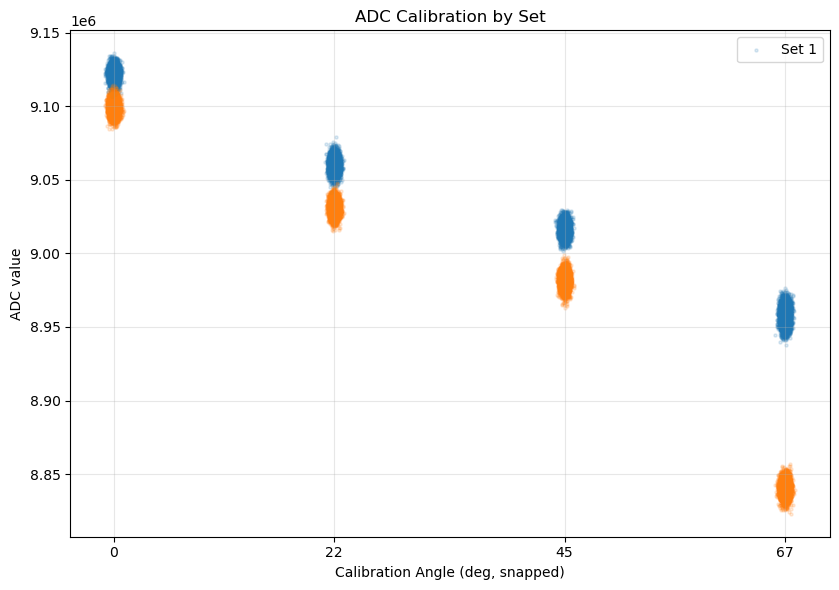

In [222]:
adc_cal_df = cam.extract_calib_means_by_set(
    adc_column="adc_ch3",             # or None to auto-pick
    exclude_name_contains=("C_Block",),
    exclude_sets=(3, 4),
    make_plot=True,
    overlay_mean=False,
    point_alpha=0.15,                 # maybe lower alpha for all points
    point_size=5,                     # smaller points for dense clouds
    jitter=0.25,
    snap_tol_deg=4.0,
    plot_all_data=True,               # <-- THIS plots all ADC samples
    canonical_angles=(0, 22, 45, 67), #  no 90
)

adc_cal_df

## Convert ADC Values to Angles Using Camera / Protractor Calibration 

In [223]:
out_cam_11_7 = cam.calibrate_trials_with_camera(
    adc_trials_first=adc_trials_first,
    adc_trials_second=adc_trials_second,
    adc_column="adc_ch3",
    poly_order=2,
    calib_kwargs=dict(
        adc_column="adc_ch3",
        exclude_name_contains=("C_Block",),
        exclude_sets=(3, 4),
        make_plot=False,
        overlay_mean=False,
        point_alpha=0.25,
        point_size=10,
        jitter=0.25,
        snap_tol_deg=4.0,
    ),
    clamp_theta=True,
    deg_min=0.0,
    deg_max=90.0,
)

adc_first_theta_11_7  = out_cam_11_7["adc_trials_first_theta"]
adc_second_theta_11_7 = out_cam_11_7["adc_trials_second_theta"]

In [224]:
ts = (
    adc_first_theta[0]["timestamp"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.zfill(12)
)

ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")

adc_first_theta[0]["time_sec"] = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()

adc_first_theta[0]

,timestamp,adc_ch0,adc_ch1,adc_ch2,adc_ch3,trial_index,source_path,theta_cam_cal,time_sec
0,153720555938,0,0,0,9159155,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.520357,0.000000
1,153720555938,0,0,0,9164617,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.160627,0.000000
2,153720555938,0,0,0,9162910,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.577881,0.000000
3,153720555938,0,0,0,9160009,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.303036,0.000000
4,153720555938,0,0,0,9162057,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.789006,0.000000
...,...,...,...,...,...,...,...,...,...
6965,153730555846,0,0,0,9158985,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,1.563827,9.999908
6966,153730555846,0,0,0,9163251,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.493969,9.999908
6967,153730555846,0,0,0,9164275,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.243664,9.999908
6968,153730555846,0,0,0,9162227,0,/Users/zdkho/Desktop/Strain-Sensor--main/CSV D...,0.746790,9.999908


## Calibration Curve 

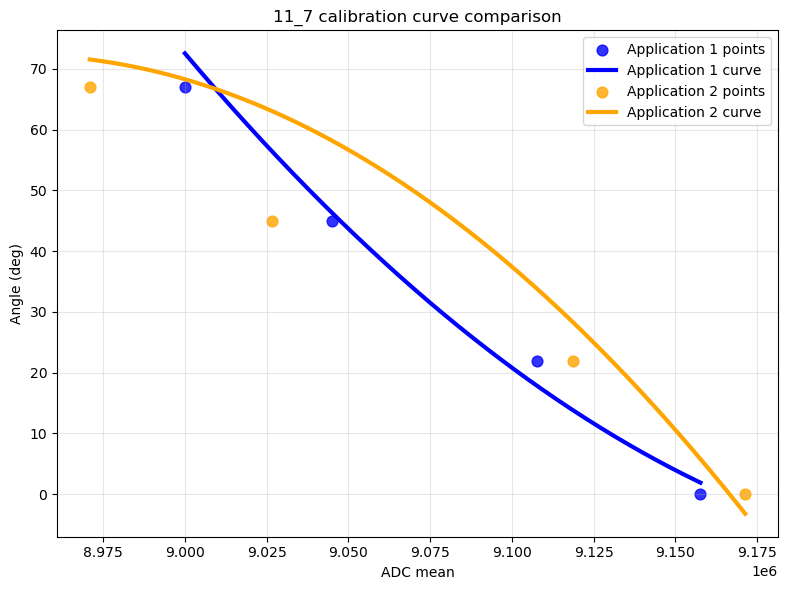

In [225]:
# ==========================================================
# Calibration curve comparison – Participant 11_7
# ==========================================================

calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

keep_angles = [0, 22, 45, 67]

calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df["angle_snap_deg"] = pd.to_numeric(calib_df["angle_snap_deg"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean", "angle_snap_deg"])

plt.figure(figsize=(8, 6))

colors = {1: "blue", 2: "orange"}

for set_id in [1, 2]:
    sub = calib_df[calib_df["set"] == set_id].copy()

    if sub.empty:
        continue

    plt.scatter(
        sub["adc_mean"],
        sub["angle_snap_deg"],
        s=60,
        alpha=0.8,
        color=colors[set_id],
        label=f"Application {set_id} points"
    )

    if set_id in coeffs:
        poly = np.poly1d(coeffs[set_id])

        x_line = np.linspace(sub["adc_mean"].min(), sub["adc_mean"].max(), 400)
        y_line = poly(x_line)

        plt.plot(
            x_line,
            y_line,
            color=colors[set_id],
            linewidth=3,
            label=f"Application {set_id} curve"
        )

plt.xlabel("ADC mean")
plt.ylabel("Angle (deg)")
plt.title("11_7 calibration curve comparison")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

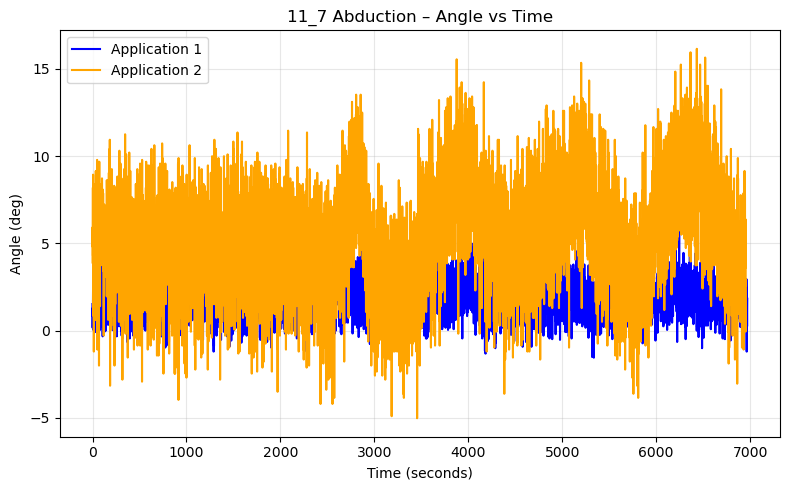

In [226]:
# ==========================================================
# 11_7 - Convert ADC to angle and plot vs time
# with robust time-axis handling
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

coeffs = out_cam["coeffs"]

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

trial_index = 0

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

# convert ADC to angle
df1["theta_from_adc"] = poly_app1(df1["adc_ch3"])
df2["theta_from_adc"] = poly_app2(df2["adc_ch3"])

# helper to choose or create time column
def get_time_series(df):
    possible_time_cols = ["relative_seconds", "time", "seconds", "t", "time_s"]
    
    for col in possible_time_cols:
        if col in df.columns:
            return df[col]

    # if no time column exists, use the index
    return df.index.to_series().reset_index(drop=True)

t1 = get_time_series(df1)
t2 = get_time_series(df2)

plt.figure(figsize=(8, 5))

plt.plot(
    t1,
    df1["theta_from_adc"].reset_index(drop=True),
    color="blue",
    label="Application 1"
)

plt.plot(
    t2,
    df2["theta_from_adc"].reset_index(drop=True),
    color="orange",
    label="Application 2"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Angle (deg)")
plt.title("11_7 Abduction – Angle vs Time")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Normalized Calibration Curve Comparison

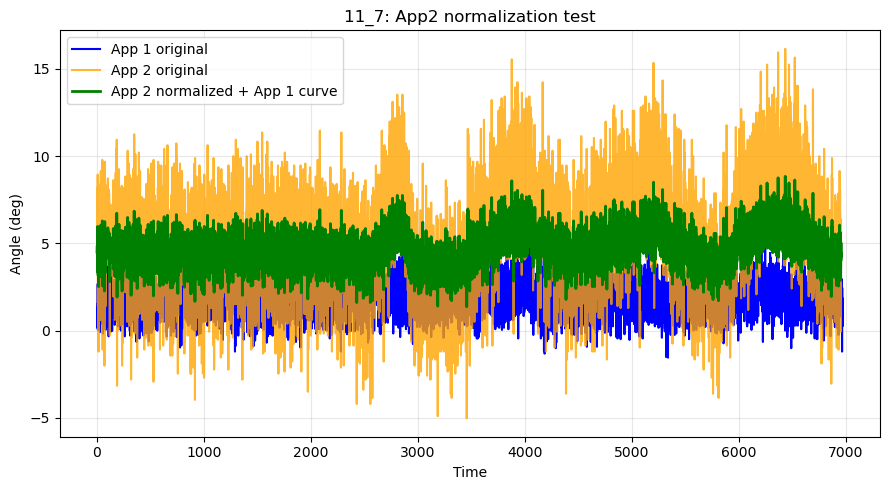

11_7 summary:
App 1 calibration ADC range: 9000016.71 to 9157667.41
App 2 calibration ADC range: 8970938.32 to 9171346.07
Mean App1 angle: 1.93
Mean App2 original angle: 5.32
Mean App2 normalized angle: 4.70


In [227]:
# ==========================================================
# 11_7: Test App2 min/max normalization + App1 calibration
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

trial_index = 0

calib_df = out_cam["calib_df"].copy()
coeffs = out_cam["coeffs"]

# keep only relevant angles for 11_7
keep_angles = [0, 22, 45, 67]
calib_df = calib_df[calib_df["angle_snap_deg"].isin(keep_angles)].copy()

calib_df["adc_mean"] = pd.to_numeric(calib_df["adc_mean"], errors="coerce")
calib_df = calib_df.dropna(subset=["adc_mean"])

# calibration ADC ranges
adc1 = calib_df[calib_df["set"] == 1]["adc_mean"]
adc2 = calib_df[calib_df["set"] == 2]["adc_mean"]

adc1_min, adc1_max = adc1.min(), adc1.max()
adc2_min, adc2_max = adc2.min(), adc2.max()

def normalize_app2_to_app1(adc):
    return (adc - adc2_min) / (adc2_max - adc2_min) * (adc1_max - adc1_min) + adc1_min

poly_app1 = np.poly1d(coeffs[1])
poly_app2 = np.poly1d(coeffs[2])

df1 = adc_first_theta[trial_index].copy()
df2 = adc_second_theta[trial_index].copy()

df1["theta_app1"] = poly_app1(df1["adc_ch3"])
df2["theta_app2"] = poly_app2(df2["adc_ch3"])

df2["adc_norm_to_app1"] = normalize_app2_to_app1(df2["adc_ch3"])
df2["theta_app2_norm_using_app1"] = poly_app1(df2["adc_norm_to_app1"])

# time axis
df1["time"] = np.arange(len(df1))
df2["time"] = np.arange(len(df2))

plt.figure(figsize=(9, 5))

plt.plot(df1["time"], df1["theta_app1"], color="blue", label="App 1 original")
plt.plot(df2["time"], df2["theta_app2"], color="orange", alpha=0.8, label="App 2 original")
plt.plot(df2["time"], df2["theta_app2_norm_using_app1"], color="green", linewidth=2, label="App 2 normalized + App 1 curve")

plt.xlabel("Time")
plt.ylabel("Angle (deg)")
plt.title("11_7: App2 normalization test")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print("11_7 summary:")
print(f"App 1 calibration ADC range: {adc1_min:.2f} to {adc1_max:.2f}")
print(f"App 2 calibration ADC range: {adc2_min:.2f} to {adc2_max:.2f}")
print(f"Mean App1 angle: {df1['theta_app1'].mean():.2f}")
print(f"Mean App2 original angle: {df2['theta_app2'].mean():.2f}")
print(f"Mean App2 normalized angle: {df2['theta_app2_norm_using_app1'].mean():.2f}")

## Plotting The Abduction Data. Note that no camera data is present for these tests 

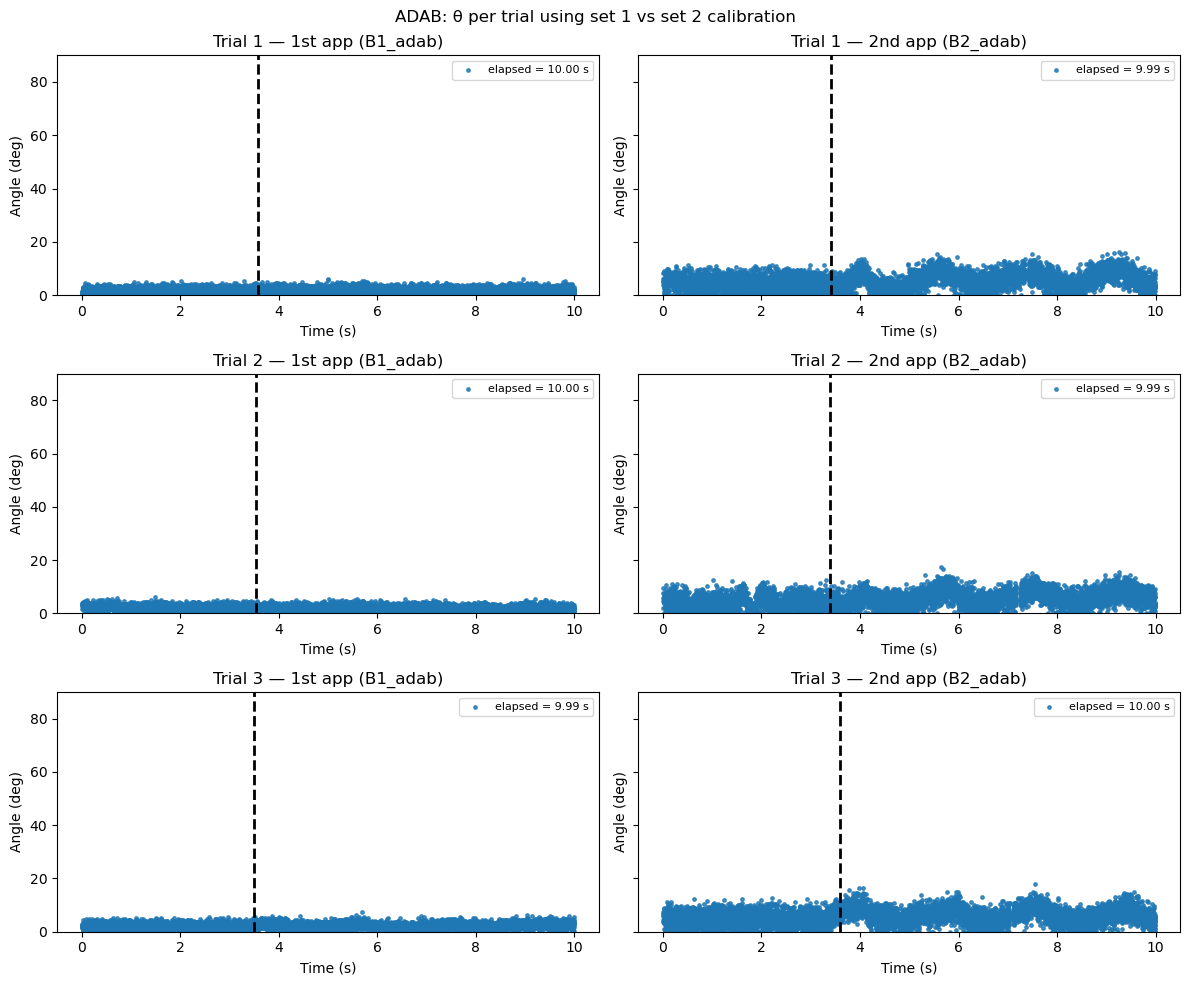

In [228]:
calib_df = out_cam.get("calib_df", None)
coeffs   = out_cam.get("coeffs", None)

# ---- 1) Skip unless ADAB pairing ----
allowed = {"B1_adab", "B2_adab"}
if {folder_suffix_first, folder_suffix_second} != allowed:
    print("SKIP: suffixes are not exactly {'B1_adab','B2_adab'}")
else:

    # ---- 2) Ensure we have coeffs for set 1 and set 2 ----
    if not isinstance(coeffs, dict):
        coeffs = {}

    if (1 not in coeffs or 2 not in coeffs):
        if calib_df is None or getattr(calib_df, "empty", True):
            print("WARNING: calib_df is empty/None and coeffs missing for set 1/2 -> cannot compute angles.")
        else:
            poly_order = 2
            for s in (1, 2):
                sub = calib_df[(calib_df["set"] == s) & calib_df["angle_snap_deg"].notna()]
                if len(sub) >= (poly_order + 1):
                    x_fit = sub["adc_mean"].to_numpy(dtype=float)
                    y_fit = sub["angle_snap_deg"].to_numpy(dtype=float)
                    coeffs[s] = np.polyfit(x_fit, y_fit, poly_order)

    # ---- 3) Convert timestamp strings HHMMSSffffff to elapsed seconds ----
    def make_elapsed_time(df, timestamp_col="timestamp"):
        """
        Convert HHMMSSffffff timestamp strings to elapsed seconds.
        Keeps ALL rows; does not collapse repeated timestamps.
        """
        ts = (
            df[timestamp_col]
            .astype(str)
            .str.replace(r"\.0$", "", regex=True)
            .str.strip()
            .str.zfill(12)
        )

        ts_dt = pd.to_datetime(ts, format="%H%M%S%f", errors="coerce")
        elapsed = (ts_dt - ts_dt.iloc[0]).dt.total_seconds()
        return elapsed.to_numpy(dtype=float)

    # ---- 4) Helper: get theta series for ALL rows ----
    def get_theta_series(
        trial_df,
        set_id,
        adc_column="adc_ch3",
        clamp=True,
        deg_min=0.0,
        deg_max=90.0,
    ):
        if trial_df is None or not hasattr(trial_df, "columns"):
            return None

        df = trial_df.copy()

        # ---- y values ----
        if "theta_cam_cal" in df.columns:
            y = pd.to_numeric(df["theta_cam_cal"], errors="coerce").to_numpy(dtype=float)
        else:
            if set_id not in coeffs:
                return None
            if adc_column not in df.columns:
                return None

            adc_vals = pd.to_numeric(df[adc_column], errors="coerce").to_numpy(dtype=float)
            p = np.poly1d(coeffs[set_id])
            y = p(adc_vals)

            if clamp:
                y = np.clip(y, deg_min, deg_max)

        # ---- x values (elapsed time) ----
        if "timestamp" in df.columns:
            x = make_elapsed_time(df)
        else:
            x = np.arange(len(y), dtype=float)

        # ---- keep only finite pairs for plotting ----
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        elapsed_sec = float(x[-1] - x[0]) if len(x) > 1 else np.nan
        return x, y, elapsed_sec

    # NEW: movement start times for FIRST application
    movement_start_times_app1 = {
        0: 3.59,   # Trial 1 — replace with your exact timestamp
        1: 3.54,   # Trial 2 — replace with your exact timestamp
        2: 3.49,   # Trial 3 — replace with your exact timestamp
    }

    # NEW: movement start times for SECOND application
    movement_start_times_app2 = {
        0: 3.42,   # Trial 1
        1: 3.39,   # Trial 2
        2: 3.59,   # Trial 3
    }

    # ---- 5) Decide how many rows to plot ----
    n = min(3, len(adc_first_theta), len(adc_second_theta))
    if n == 0:
        print("Nothing to plot: n=0 (your trial lists are empty).")
    else:
        fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=True)

        for r in range(3):
            for c in range(2):
                if r >= n:
                    axes[r, c].axis("off")

        missing = 0

        for i in range(n):
            # ---- LEFT COLUMN (set 1) ----
            ax = axes[i, 0]

            xy = get_theta_series(
                adc_first_theta[i],
                set_id=1,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 1)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for FIRST application
                if i in movement_start_times_app1:
                    ax.axvline(
                        x=movement_start_times_app1[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 1st app ({folder_suffix_first})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

            # ---- RIGHT COLUMN (set 2) ----
            ax = axes[i, 1]

            xy = get_theta_series(
                adc_second_theta[i],
                set_id=2,
                adc_column="adc_ch3",
            )

            if xy is None:
                missing += 1
                ax.text(0.5, 0.5, "No theta (set 2)", ha="center", va="center")
            else:
                x, y, elapsed_sec = xy
                label = f"elapsed = {elapsed_sec:.2f} s"
                ax.scatter(x, y, s=6, alpha=0.8, label=label)

                # NEW: vertical line for SECOND application
                if i in movement_start_times_app2:
                    ax.axvline(
                        x=movement_start_times_app2[i],
                        color="black",
                        linewidth=2,
                        linestyle="--"
                    )

                ax.legend(loc="best", fontsize=8)

            ax.set_title(f"Trial {i+1} — 2nd app ({folder_suffix_second})")
            ax.set_ylabel("Angle (deg)")
            ax.set_xlabel("Time (s)")
            ax.set_ylim(0, 90)

        if missing > 0:
            print(f"NOTE: {missing} subplot(s) missing theta.")

        fig.suptitle("ADAB: θ per trial using set 1 vs set 2 calibration", y=0.98)
        plt.tight_layout()
        plt.show()

## Standard Deviation Calculations 1st Application 11-7 (rest / moving)

In [229]:
# use participant-specific calibrated output
adc_first_theta_11_7 = out_cam_11_7["adc_trials_first_theta"]

# onset times (s) for first application trials 1–3
onsets = [3.59, 3.54, 3.49]

trial_names = [
    "11_7_app1_trial_1",
    "11_7_app1_trial_2",
    "11_7_app1_trial_3"
]

results_11_7_app1 = []

for i, onset in enumerate(onsets):
    df = adc_first_theta_11_7[i].copy()

    # convert raw timestamp to elapsed seconds
    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    # segment angle data into rest and motion periods
    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results_11_7_app1.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

df_11_7_app1 = pd.DataFrame(results_11_7_app1).set_index("trial")

print(df_11_7_app1)

print("\nMean rest std:", df_11_7_app1["rest_std_deg"].mean())
print("Mean motion std:", df_11_7_app1["motion_std_deg"].mean())
print("Std of rest stds:", df_11_7_app1["rest_std_deg"].std())
print("Std of motion stds:", df_11_7_app1["motion_std_deg"].std())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_7_app1_trial_1     3.59    2500      4385      1.049262        1.216218
11_7_app1_trial_2     3.54    2465      4420      0.355994        0.666951
11_7_app1_trial_3     3.49    2430      4470      0.323606        0.690596

Mean rest std: 0.5762872801310511
Mean motion std: 0.8579214585465347
Std of rest stds: 0.40992798341983
Std of motion stds: 0.31051895282639735


## Standard Deviation Calculations 2nd Application 11-7 (rest / moving)

In [230]:
# use participant-specific calibrated output
adc_second_theta_11_7 = out_cam_11_7["adc_trials_second_theta"]

# onset times (seconds) for second application trials
onsets = [3.42, 3.39, 3.59]

trial_names = [
    "11_7_app2_trial_1",
    "11_7_app2_trial_2",
    "11_7_app2_trial_3"
]

results_11_7_app2 = []

for i, onset in enumerate(onsets):

    df = adc_second_theta_11_7[i].copy()

    # convert timestamp to elapsed seconds
    ts = pd.to_datetime(df["timestamp"].astype(str), format="%H%M%S%f")
    df["time_sec"] = (ts - ts.iloc[0]).dt.total_seconds()

    # REST segment
    rest_vals = df.loc[
        (df["time_sec"] >= 0) & (df["time_sec"] <= onset),
        "theta_cam_cal"
    ]

    # MOTION segment
    motion_vals = df.loc[
        (df["time_sec"] >= onset + 0.1) & (df["time_sec"] <= 10),
        "theta_cam_cal"
    ]

    results_11_7_app2.append({
        "trial": trial_names[i],
        "onset_s": onset,
        "n_rest": len(rest_vals),
        "n_motion": len(motion_vals),
        "rest_std_deg": rest_vals.std(),
        "motion_std_deg": motion_vals.std()
    })

# create summary dataframe
df_11_7_app2 = pd.DataFrame(results_11_7_app2).set_index("trial")

print(df_11_7_app2)

print("\nMean rest std:", df_11_7_app2["rest_std_deg"].mean())
print("Mean motion std:", df_11_7_app2["motion_std_deg"].mean())
print("Std of rest stds:", df_11_7_app2["rest_std_deg"].std())
print("Std of motion stds:", df_11_7_app2["motion_std_deg"].std())

                   onset_s  n_rest  n_motion  rest_std_deg  motion_std_deg
trial                                                                     
11_7_app2_trial_1     3.42    2385      4500      1.491233        1.629601
11_7_app2_trial_2     3.39    2360      4540      1.512658        1.661392
11_7_app2_trial_3     3.59    2500      4375      1.493311        1.568206

Mean rest std: 1.4990673432586832
Mean motion std: 1.619732867697925
Std of rest stds: 0.011815869649711739
Std of motion stds: 0.04736998708841476


## Pooled Standard Deviation Data Across All Participants 

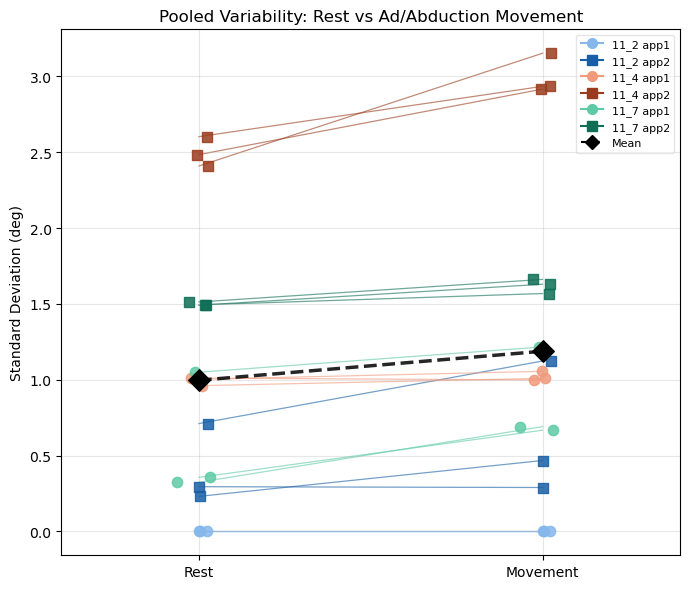


Mean std (Rest):     0.9962 deg
Mean std (Movement): 1.1877 deg
Difference:          0.1915 deg

Pooled dataframe used for plotting:


,participant,application,trial,rest_std_deg,motion_std_deg
0,11_2,app1,trial_1,0.000000,0.000000
1,11_2,app1,trial_2,0.000000,0.000000
2,11_2,app1,trial_3,0.000000,0.000000
3,11_2,app2,trial_1,0.230677,0.467223
4,11_2,app2,trial_2,0.294593,0.289201
5,11_2,app2,trial_3,0.710665,1.123329
6,11_4,app1,trial_1,0.960683,1.008854
7,11_4,app1,trial_2,1.011029,0.998020
8,11_4,app1,trial_3,1.002522,1.055381
9,11_4,app2,trial_1,2.409085,3.152661



Counts by participant and application:


,participant,application,n_trials
0,11_2,app1,3
1,11_2,app2,3
2,11_4,app1,3
3,11_4,app2,3
4,11_7,app1,3
5,11_7,app2,3



Summary statistics:


,count,mean,std,median,min,max
condition,,,,,,
Movement,18,1.187686,0.989105,1.032118,0.0,3.152661
Rest,18,0.996221,0.859310,0.981602,0.0,2.602506


In [231]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

summary_tables = {
    ("11_2", "app1"): df_11_2_app1,
    ("11_2", "app2"): df_11_2_app2,
    ("11_4", "app1"): df_11_4_app1,
    ("11_4", "app2"): df_11_4_app2,
    ("11_7", "app1"): df_11_7_app1,
    ("11_7", "app2"): df_11_7_app2,
}

combined_dfs = []

for (participant, application), df in summary_tables.items():
    df = df.copy()
    if "trial" not in df.columns:
        df["trial"] = [f"trial_{i+1}" for i in range(len(df))]
    df["participant"] = participant
    df["application"] = application
    combined_dfs.append(
        df[["participant", "application", "trial", "rest_std_deg", "motion_std_deg"]]
    )

pooled_df = pd.concat(combined_dfs, ignore_index=True)

# ── Color scheme: each participant gets two shades (app1=light, app2=dark) ──
group_colors = {
    ("11_2", "app1"): "#85B7EB",   # blue light
    ("11_2", "app2"): "#185FA5",   # blue dark
    ("11_4", "app1"): "#F0997B",   # coral light
    ("11_4", "app2"): "#993C1D",   # coral dark
    ("11_7", "app1"): "#5DCAA5",   # teal light
    ("11_7", "app2"): "#0F6E56",   # teal dark
}

fig, ax = plt.subplots(figsize=(7, 6))

# Draw pair lines first (behind points)
for _, row in pooled_df.iterrows():
    color = group_colors[(row["participant"], row["application"])]
    ax.plot(
        [0, 1],
        [row["rest_std_deg"], row["motion_std_deg"]],
        color=color,
        linewidth=0.9,
        alpha=0.6,
        zorder=1,
    )

# Draw scatter points on top
for (participant, application), color in group_colors.items():
    sub = pooled_df[
        (pooled_df["participant"] == participant) &
        (pooled_df["application"] == application)
    ]
    rng = np.random.default_rng(hash(participant + application) % (2**32))
    jitter = rng.normal(0, 0.03, size=len(sub))
    marker = "o" if application == "app1" else "s"
    ax.scatter(
        0 + jitter, sub["rest_std_deg"],
        color=color, s=55, alpha=0.85, zorder=3, marker=marker,
    )
    ax.scatter(
        1 + jitter, sub["motion_std_deg"],
        color=color, s=55, alpha=0.85, zorder=3, marker=marker,
    )

# Mean line
rest_mean = pooled_df["rest_std_deg"].mean()
move_mean = pooled_df["motion_std_deg"].mean()

ax.plot(
    [0, 1], [rest_mean, move_mean],
    color="black", linewidth=2.5, linestyle="--",
    zorder=4, alpha=0.85,
)
ax.scatter(
    [0, 1], [rest_mean, move_mean],
    color="black", s=120, marker="D", zorder=5,
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Rest", "Movement"])
ax.set_xlim(-0.4, 1.4)
ax.set_ylabel("Standard Deviation (deg)")
ax.set_title("Pooled Variability: Rest vs Ad/Abduction Movement")
ax.grid(True, alpha=0.3)

legend_handles = [
    mlines.Line2D([], [], color=group_colors[(p, a)], marker="o" if a=="app1" else "s",
                  linestyle="-", markersize=7, label=f"{p} {a}")
    for p, a in group_colors.keys()
]
legend_handles.append(
    mlines.Line2D([], [], color="black", marker="D", linestyle="--",
                  markersize=7, label="Mean")
)
ax.legend(handles=legend_handles, framealpha=0.5, fontsize=8)

plt.tight_layout()
plt.show()

# ── Mean std summary ──────────────────────────────────────────────────────────
print(f"\nMean std (Rest):     {rest_mean:.4f} deg")
print(f"Mean std (Movement): {move_mean:.4f} deg")
print(f"Difference:          {move_mean - rest_mean:.4f} deg")

print("\nPooled dataframe used for plotting:")
display(pooled_df)

print("\nCounts by participant and application:")
display(pooled_df.groupby(["participant", "application"]).size().reset_index(name="n_trials"))

print("\nSummary statistics:")
long_df = pooled_df.melt(
    id_vars=["participant", "application", "trial"],
    value_vars=["rest_std_deg", "motion_std_deg"],
    var_name="condition",
    value_name="std_deg",
)
long_df["condition"] = long_df["condition"].replace({
    "rest_std_deg": "Rest",
    "motion_std_deg": "Movement"
})
display(long_df.groupby("condition")["std_deg"].agg(["count", "mean", "std", "median", "min", "max"]))